In [1]:
import  numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [18]:
df=pd.read_csv(r"C:\Users\Aditya Kumar\OneDrive\Desktop\ML_project_1\insurance.csv")

In [6]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


#### EDA

In [7]:
df.shape

(1338, 7)

In [8]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

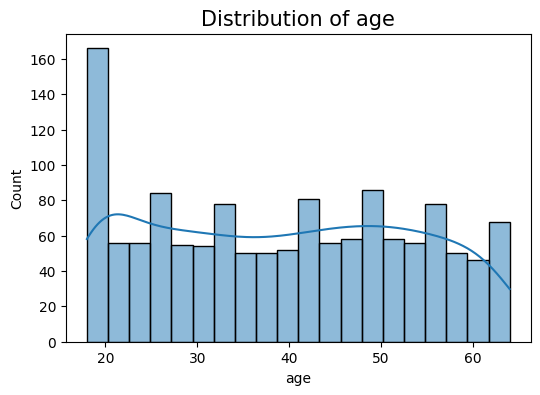

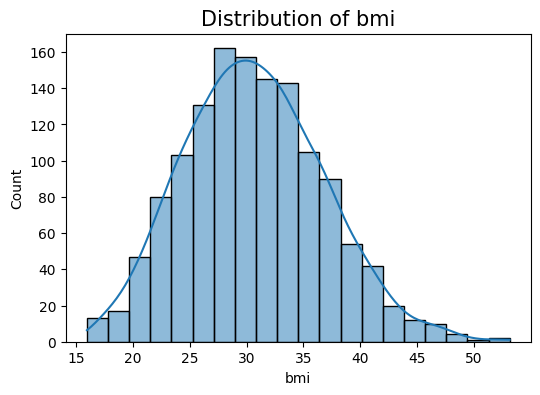

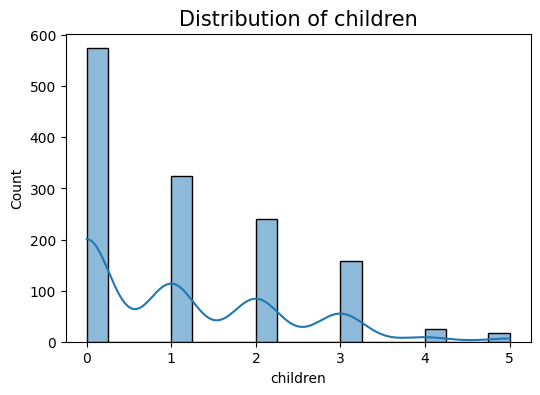

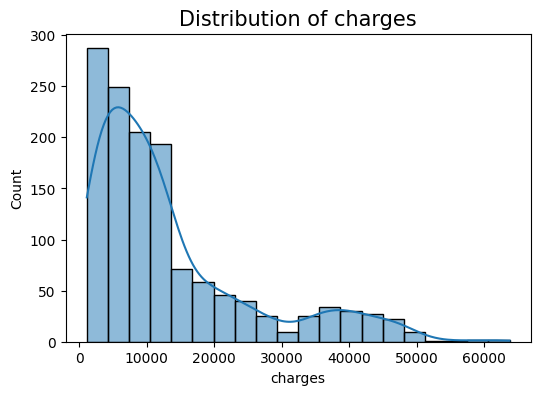

In [ ]:
numeric_columns=['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)
    plt.title(f'Distribution of {col}',fontsize=15)
    plt.show()
# from plots we obtain that the distribution of age and bmi is right skewed and the distribution of charges is highly right skewed. The distribution of children is left skewed.
# also, we can see that the distribution of charges is highly right skewed which indicates that there are some outliers present in the data.

<Axes: xlabel='children', ylabel='count'>

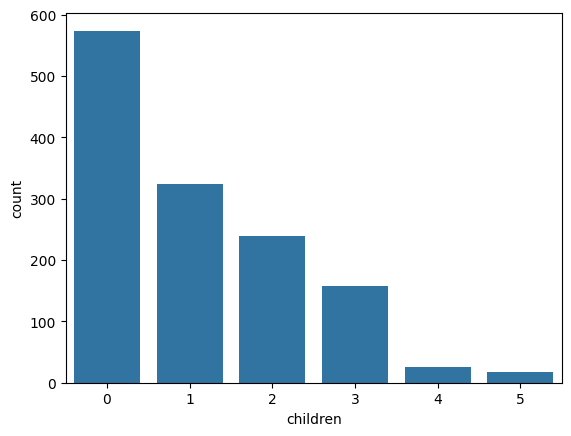

In [15]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

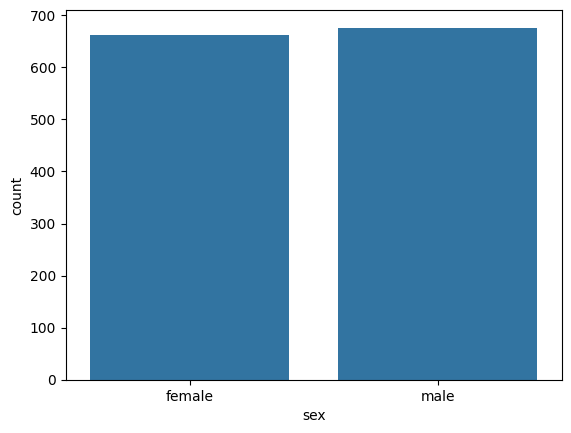

In [20]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

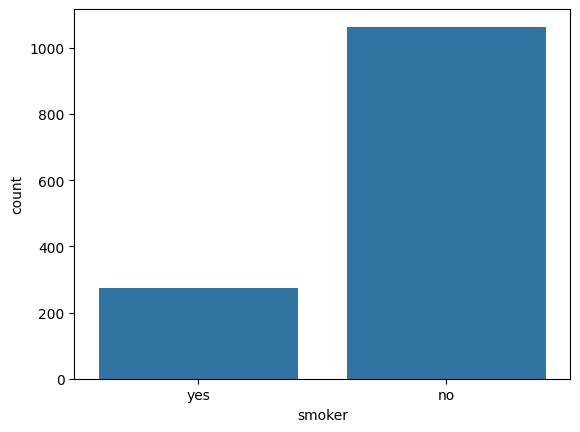

In [21]:
sns.countplot(x=df['smoker'])

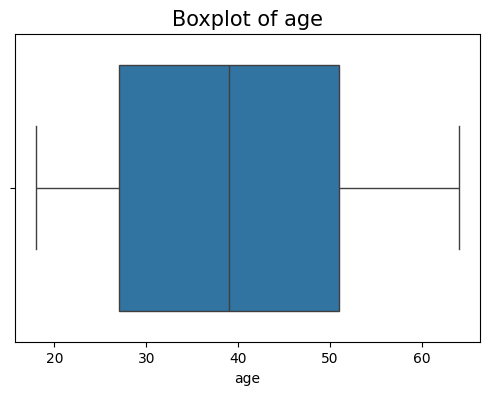

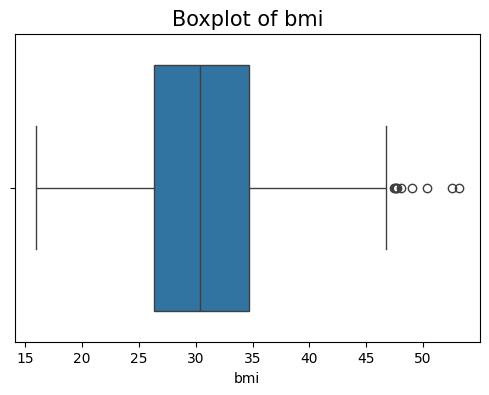

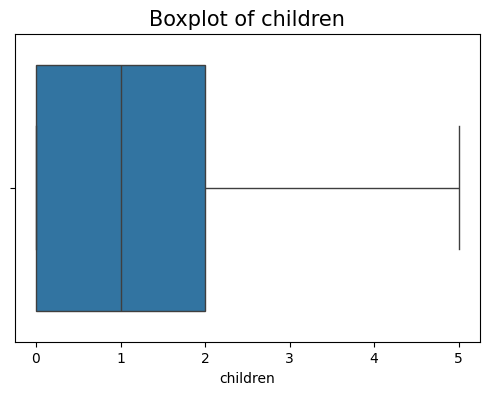

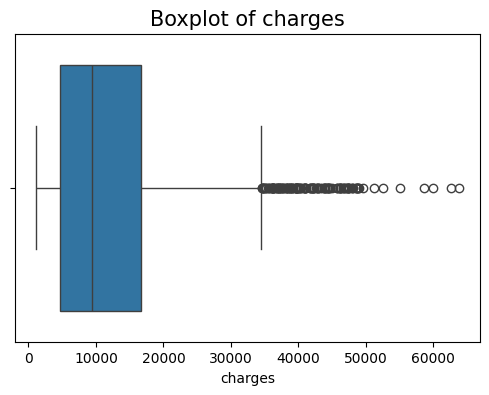

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}',fontsize=15)
    plt.show()
# from the boxplots we can see that there are some outliers present in the data. The outliers are present in the columns age, bmi and charges. The outliers are not present in the column children.
# so, we can say that the columns age, bmi and charges are not normally distributed. The column children is normally distributed. and the column children is left skewed. The column age and bmi are right skewed. The column charges is highly right skewed.
# we do this beacuse the presence of outliers can affect the performance of the model. So, we need to handle the outliers present in the data.


<Axes: >

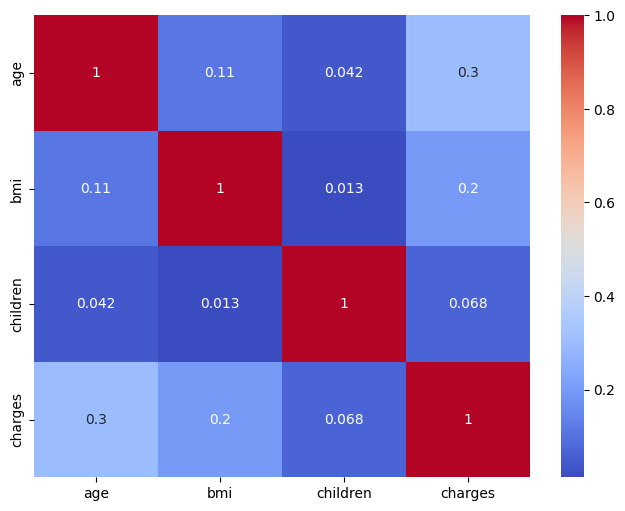

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

### Data Cleaning and Processing

In [24]:
df_cleaned=df.copy()

In [25]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [27]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [28]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [29]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [31]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [32]:
# label encdong for sex
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})

In [33]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [34]:
# label encdong for smoker
df_cleaned['smoker']=df_cleaned['smoker'].map({'no':0,'yes':1})

In [35]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [36]:
df_cleaned.rename(columns={'sex': 'is_female', 'smoker': 'is_smoker'}, inplace=True)

In [37]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [38]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [39]:
# one hot encoding for region
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [40]:
df_cleaned.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


In [ ]:
# from the above code we have done the following things:
# 1. We have imported the necessary libraries.
# 2. We have loaded the data into a pandas dataframe.
# 3. We have performed some basic EDA on the data to understand the distribution of the data and to check for any missing values or outliers.
# 4. We have handled the outliers present in the data by using the boxplots.
# 5. We have performed label encoding for the categorical variables 'sex' and 'smoker'.
# 6. We have performed one hot encoding for the categorical variable 'region'.  


In [ ]:
# feature engineering and extracting new features from the existing features can be done in the next step. We can also perform feature selection to select the most important features for the model. We can also perform feature scaling to scale the features to a similar range. We can also perform feature transformation to transform the features to a normal distribution. We can also perform feature extraction to extract new features from the existing features. We can also perform feature selection to select the most important features for the model. We can also perform feature scaling to scale the features to a similar range. We can also perform feature transformation to transform the features to a normal distribution. We can also perform feature extraction to extract new features from the existing features.


# Feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

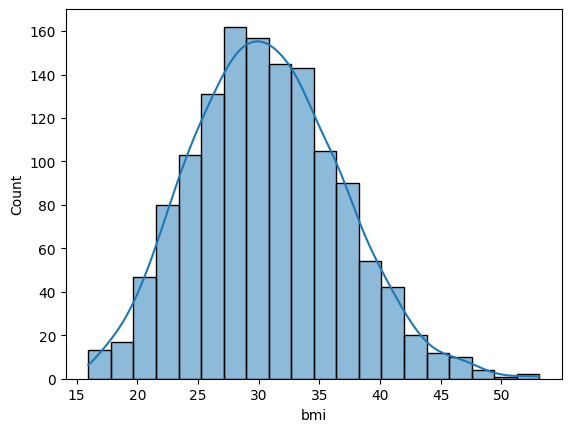

In [41]:
sns.histplot(df['bmi'],kde=True,bins=20)

In [42]:
df_cleaned['bmi_category']=pd.cut(df_cleaned['bmi'],
                                  bins=[0,18.5,24.9,29.9,float('inf')]
                                  ,labels=['underweight','normal','overweight','obese'])

In [43]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,obese
2,28,0,33.000,3,0,4449.46200,False,True,False,obese
3,33,0,22.705,0,0,21984.47061,True,False,False,normal
4,32,0,28.880,0,0,3866.85520,True,False,False,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,obese
1334,18,1,31.920,0,0,2205.98080,False,False,False,obese
1335,18,1,36.850,0,0,1629.83350,False,True,False,obese
1336,21,1,25.800,0,0,2007.94500,False,False,True,overweight


In [44]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [46]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,False,False,True,False,True,False
1,18,0,33.770,1,0,1725.55230,False,True,False,False,False,True
2,28,0,33.000,3,0,4449.46200,False,True,False,False,False,True
3,33,0,22.705,0,0,21984.47061,True,False,False,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,False,False,True
1334,18,1,31.920,0,0,2205.98080,False,False,False,False,False,True
1335,18,1,36.850,0,0,1629.83350,False,True,False,False,False,True
1336,21,1,25.800,0,0,2007.94500,False,False,True,False,True,False


In [47]:
df_cleaned=df_cleaned.astype(int)

In [48]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


In [49]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [50]:
# standard scaler for bmi and age
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
col=['bmi','age','children']
df_cleaned[col]=scaler.fit_transform(df_cleaned[col])

In [51]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


Text(0.5, 0, 'Features')

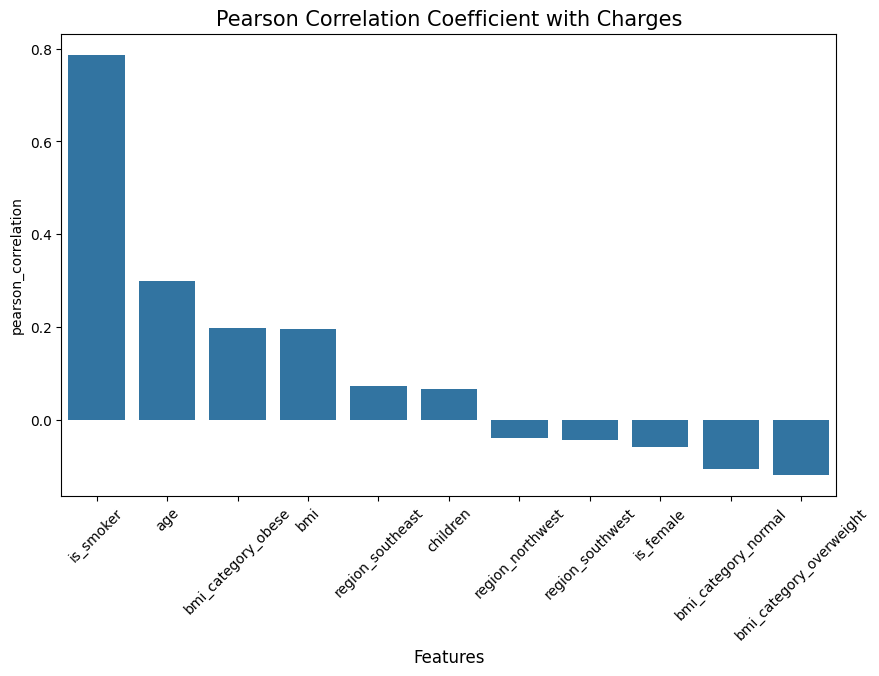

In [54]:
# pearson correlation coefficient is a measure of the linear correlation between two variables. It ranges from -1 to 1, where 1 indicates a perfect positive correlation, -1 indicates a perfect negative correlation, and 0 indicates no correlation. The Pearson correlation coefficient can be calculated using the following formula:
from scipy.stats import pearsonr
selected_features=['age','bmi','children','is_female','is_smoker',
                   'region_northwest','region_southeast','region_southwest','bmi_category_normal',
                   'bmi_category_overweight','bmi_category_obese']
correlations={
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0] 
    for feature in selected_features
}
correlations_df=pd.DataFrame.from_dict(correlations,orient='index',columns=['pearson_correlation'])
correlations_df.sort_values(by='pearson_correlation',ascending=False,inplace=True)
correlations_df
plt.figure(figsize=(10,6))
sns.barplot(x=correlations_df.index,y='pearson_correlation',data=correlations_df)
plt.xticks(rotation=45) 
plt.title('Pearson Correlation Coefficient with Charges',fontsize=15)
plt.xlabel('Features',fontsize=12)

In [57]:
cat_features=['is_female','is_smoker','region_northwest','region_southeast','region_southwest',
              'bmi_category_normal','bmi_category_overweight','bmi_category_obese']
# chi square test for categorical features
from scipy.stats import chi2_contingency
import pandas as pd
alpha=0.05
chi2_results={}
df_cleaned['charges_bins']=pd.qcut(df_cleaned['charges'],q=4,labels=False)
for col in cat_features:
    contingency_table=pd.crosstab(df_cleaned[col],df_cleaned['charges_bins'])
    chi2_stat,p_value, _, _ = chi2_contingency(contingency_table)
    decision = 'Reject Null Hypothesis' if p_value < alpha else 'Accept Null (drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'P-value': p_value,
        'Decision': decision
    }
chi2_df=pd.DataFrame.from_dict(chi2_results,orient='index')
chi2_df.sort_values(by='P-value',ascending=True,inplace=True)
chi2_df


,chi2_statistic,P-value,Decision
is_smoker,848.219178,1.507478e-183,Reject Null Hypothesis
region_southeast,15.998167,1.134966e-03,Reject Null Hypothesis
is_female,10.258784,1.648974e-02,Reject Null Hypothesis
bmi_category_obese,7.654464,5.371967e-02,Accept Null (drop Feature)
region_southwest,5.091893,1.651906e-01,Accept Null (drop Feature)
bmi_category_normal,4.263673,2.343638e-01,Accept Null (drop Feature)
bmi_category_overweight,4.201575,2.405042e-01,Accept Null (drop Feature)
region_northwest,1.134240,7.688154e-01,Accept Null (drop Feature)


In [58]:
final_df=df_cleaned[['age','bmi','children','is_female','is_smoker','region_northwest','region_southeast','region_southwest','bmi_category_normal',
                  'bmi_category_overweight','bmi_category_obese','charges']
]   
final_df

,age,bmi,children,is_female,is_smoker,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese,charges
0,-1.440418,-0.517949,-0.909234,1,1,0,0,1,0,1,0,16884
1,-1.511647,0.462463,-0.079442,0,0,0,1,0,0,0,1,1725
2,-0.799350,0.462463,1.580143,0,0,0,1,0,0,0,1,4449
3,-0.443201,-1.334960,-0.909234,0,0,1,0,0,1,0,0,21984
4,-0.514431,-0.354547,-0.909234,0,0,1,0,0,0,1,0,3866
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,-0.027743,1.580143,0,0,1,0,0,0,0,1,10600
1334,-1.511647,0.135659,-0.909234,1,0,0,0,0,0,0,1,2205
1335,-1.511647,0.952670,-0.909234,1,0,0,1,0,0,0,1,1629
1336,-1.297958,-0.844753,-0.909234,1,0,0,0,1,0,1,0,2007


In [59]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
